<a href="https://colab.research.google.com/github/bhargav-pichikala/NNDL/blob/main/Body_part_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install ftfy regex tqdm
!git clone https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
Cloning into 'CLIP'...
remote: Enumerating objects: 256, done.
remote: Total 256 (delta 0), reused 0 (delta 0), pack-reused 256 (from 1)
Receiving objects: 100% (256/256), 8.87 MiB | 32.21 MiB/s, done.
Resolving deltas: 100% (136/136), done.


Saving nose.jpg to nose (1).jpg
Uploaded image:


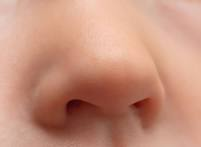

Predicted body part: nose


In [16]:
import torch
import sys
sys.path.append('./CLIP')
import clip
from PIL import Image
from google.colab import files
import io

device="cuda" if torch.cuda.is_available() else "cpu"
model,preprocess=clip.load("ViT-B/32",device=device)

body_parts=[
    "hand","palm","fingers","thumb",
    "arm","elbow","shoulder",
    "leg","knee","foot","ankle","toe",
    "face","head","eye","ear","nose","mouth",
    "neck",
    "torso","chest","abdomen","back",
    "waist","hip"
]

text=clip.tokenize([f"a photo of a {bp}" for bp in body_parts]).to(device)

uploaded=files.upload()
img_name=list(uploaded.keys())[0]
original_image=Image.open(io.BytesIO(uploaded[img_name])).convert("RGB")
image=preprocess(original_image).unsqueeze(0).to(device)

print("Uploaded image:")
display(original_image)

with torch.no_grad():
    image_features=model.encode_image(image)
    text_features=model.encode_text(text)
    similarity=(image_features @ text_features.T).softmax(dim=-1)

idx=similarity.argmax().item()
print("Predicted body part:",body_parts[idx])